# Icescopy counts to INP per litre of air with INP-toolkit

Load counts, assign the sample and blank, calculate concentrations, and compare
MLE and Average with the supplied OLAF result. The final section shows the
same workflow in one call.

Run from this repository or its `notebook` folder.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

# Import the package from this checkout.
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import inptk

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


## 1. Read the data

`Sample_0`–`Sample_4` belong to one original sample; `Sample_5` is the blank.
The export supplies dilution factors and 50 µL droplet volumes.


In [2]:
data_dir = Path("/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun")
sample_inputs = [f"Sample_{i}" for i in range(5)]

reference = inptk.read_csu_csv(
    data_dir / "INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv"
)


The count CSV lacks the air volume, suspension volume, and filter fraction;
use the values from the matching OLAF reference. Assign `Sample_5` as the blank
and set its dilution to 1.


In [3]:
metadata = {
    name: {
        "air_volume_L": reference.metadata["air_volume_L"],
        "suspension_volume_mL": reference.metadata["suspension_volume_mL"],
        "filter_fraction_used": reference.metadata["filter_fraction_used"],
    }
    for name in sample_inputs
}
metadata["Sample_5"] = {"sample_type": "other", "dilution": 1}

sample_map = {name: "CRG_M1" for name in sample_inputs}
sample_map["Sample_5"] = "water"

experiment = inptk.read_icescopy(
    data_dir / "freeze_count_timeseries.csv",
    metadata=metadata,
    sample_map=sample_map,
    water_blank_map={name: ["Sample_5"] for name in sample_inputs},
    run_id="M1-base-rerun",
)
experiment.counts.to_dataframe().head()


,sample_id,temperature_C,n_total,n_frozen,fraction_frozen,time_s,picture_id,measurement_id,run_id,cycle_id,observation_id
0,CRG_M1,20.634,32.0,0.0,0.0,0.00,NaN,Sample_0,M1-base-rerun,0,0
1,CRG_M1,20.632,32.0,0.0,0.0,0.34,NaN,Sample_0,M1-base-rerun,0,1
2,CRG_M1,20.634,32.0,0.0,0.0,1.27,NaN,Sample_0,M1-base-rerun,0,2
3,CRG_M1,20.615,32.0,0.0,0.0,2.27,NaN,Sample_0,M1-base-rerun,0,3
4,CRG_M1,20.610,32.0,0.0,0.0,3.27,NaN,Sample_0,M1-base-rerun,0,4


## 2. Inspect counts and frozen fractions

`frozen_fraction()` divides frozen counts by total counts at each original
observation. All count rows are used, including rows without an image ID.
Here we plot cycle 0; repeated cycles remain separate.


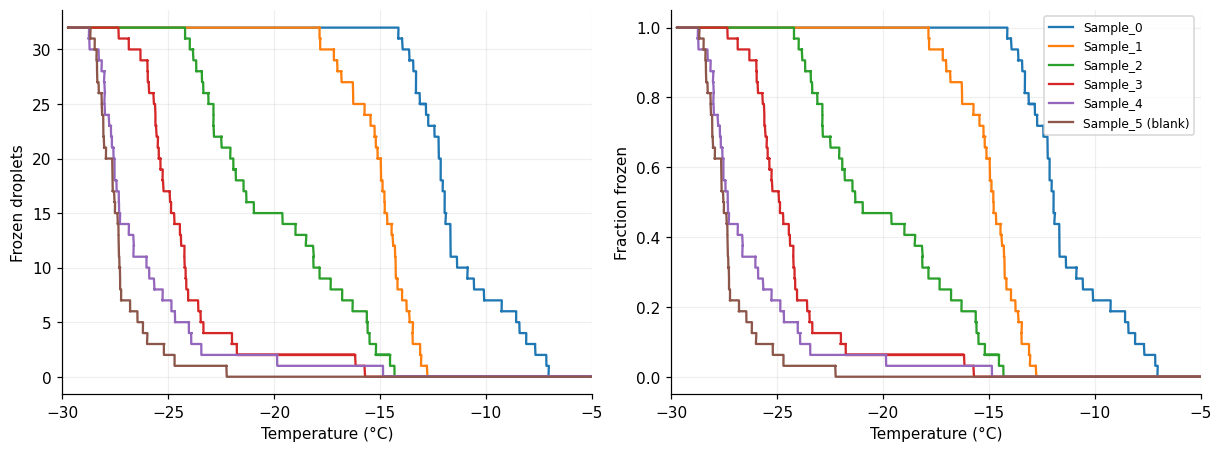

In [4]:
fractions = inptk.frozen_fraction(experiment)
observed = fractions.select(cycle_id="0").to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for name, frame in observed.groupby("measurement_id", sort=False):
    label = f"{name} (blank)" if name == "Sample_5" else name
    axes[0].plot(frame.temperature_C, frame.n_frozen, label=label)
    axes[1].plot(frame.temperature_C, frame.fraction_frozen, label=label)
for ax in axes:
    ax.set(xlabel="Temperature (°C)", xlim=(-30, -5))
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Frozen droplets")
axes[1].set_ylabel("Fraction frozen")
axes[1].legend(fontsize=8)
plt.show()


## 3. Choose the temperature ranges

Average uses automatic limits: exhaust the least diluted input, then move to
the next. Require at least 3 liquid wells, and at least 3 frozen wells for later
inputs. The first input keeps its initial observations. The package shortens
ranges when needed for a nondecreasing curve; no concentrations are changed.

MLE uses the manually chosen limits below. `max_C` is the warmest allowed
temperature for that input; omitted limits leave the corresponding end open.


In [5]:
curves = {"CRG_M1": {"inputs": sample_inputs, "cycle": "0"}}

average_limits = inptk.suggest_temperature_ranges(
    experiment, curves=curves, min_frozen=3, min_unfrozen=3,
    temperature_step_C=0.5, temperature_method="latest",
)
mle_limits = {
    "Sample_1": {"max_C": -10},
    "Sample_2": {"max_C": -15},
    "Sample_3": {"max_C": -20},
    "Sample_4": {"max_C": -25},
}
pd.DataFrame.from_dict(average_limits.temperature_ranges_C, orient="index")


,min_C,max_C
Sample_0,-13.621,20.655
Sample_1,-17.164,-13.622
Sample_2,-23.808,-17.166
Sample_3,-26.308,-23.817
Sample_4,-26.845,-26.310


## 4. Calculate each input separately

Use Average with the suggested limits. Select counts on a 0.5 °C grid before
calculation; `latest` uses the last observation at or warmer than the target.
Start and end temperatures are omitted, so the grid uses the measured limits.

The assigned raw blank and its uncertainty are included. Convert the resulting
suspension concentrations to INP per litre of air.


In [6]:
individual = inptk.cumulative_spectrum(
    fractions, experiment=experiment, method="average",
    temperature_step_C=0.5, temperature_method="latest",
    temperature_ranges_C=average_limits.temperature_ranges_C,
)
individual_air = inptk.convert_concentration(
    individual, experiment.samples, basis="sampled_air",
)
individual_air.to_dataframe().head()


,measurement_id,run_id,cycle_id,sample_id,temperature_C,n_total,n_frozen,fraction_frozen,time_s,picture_id,...,dilution_fold,water_blank_ids,source_observations,uncertainty_method,correction_state,at_zero_boundary,is_extrapolated,water_blank_observations,blank_n_frozen,blank_n_total
0,Sample_0,M1-base-rerun,0,CRG_M1,20.655,32.0,0.0,0.0,5.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
1,Sample_0,M1-base-rerun,0,CRG_M1,20.155,32.0,0.0,0.0,286.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
2,Sample_0,M1-base-rerun,0,CRG_M1,19.655,32.0,0.0,0.0,382.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
3,Sample_0,M1-base-rerun,0,CRG_M1,19.155,32.0,0.0,0.0,452.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
4,Sample_0,M1-base-rerun,0,CRG_M1,18.655,32.0,0.0,0.0,513.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0


The plotting helper draws concentrations and optional uncertainty shading.
Zero and non-finite values cannot be drawn on a log axis. Separate segments
keep lines from crossing excluded parts of a curve.


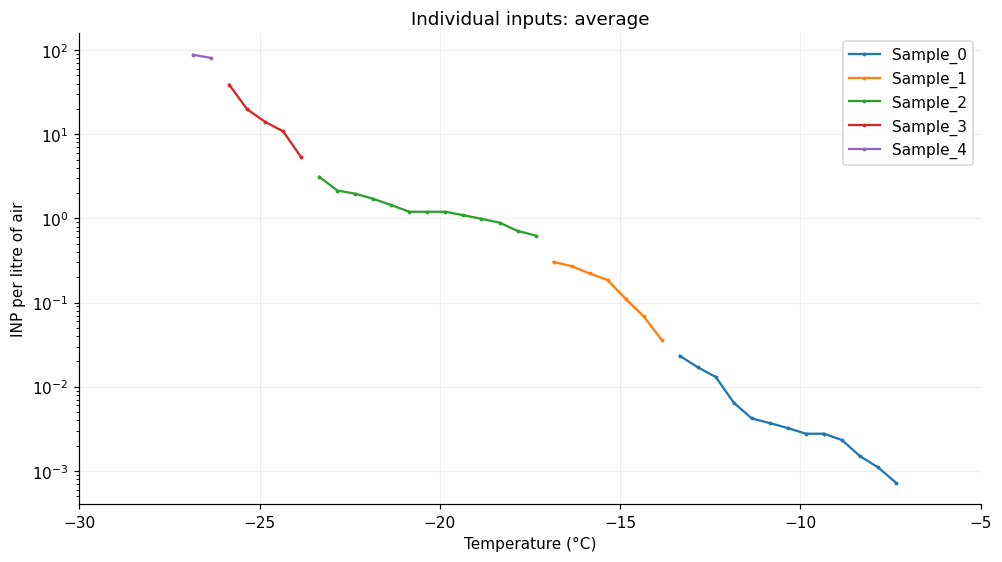

In [7]:
def plot_spectrum(ax, frame, label, color, uncertainty=False):
    segments = frame.groupby("segment_id", sort=False) if "segment_id" in frame else [(0, frame)]
    for i, (_, segment) in enumerate(segments):
        concentration = segment.concentration
        visible = np.isfinite(concentration) & (concentration > 0)
        ax.plot(segment.temperature_C, concentration.where(visible), ".-",
                color=color, label=label if i == 0 else None, markersize=3)
        if uncertainty:
            lower = concentration - segment.lower_error
            upper = concentration + segment.upper_error
            band = visible & (lower > 0) & np.isfinite(lower) & np.isfinite(upper)
            ax.fill_between(segment.temperature_C, lower.where(band), upper.where(band),
                            color=color, alpha=0.15)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for i, (name, frame) in enumerate(
    individual_air.select(sample_id="CRG_M1", cycle_id="0").to_dataframe()
    .groupby("measurement_id", sort=False)
):
    plot_spectrum(ax, frame, name, f"C{i}")
ax.set(yscale="log", xlabel="Temperature (°C)", ylabel="INP per litre of air",
       xlim=(-30, -5), title="Individual inputs: average")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 5. Combine inputs, step by step

MLE fits the sample and blank freezing histories together, with a monotone
sample curve. Average estimates concentration at each temperature; where input
ranges overlap, it takes an equal-weight mean. Here the automatic Average
limits select one dilution at a time.


In [8]:
mle = inptk.estimate_concentration(
    fractions, experiment=experiment, method="mle", curves=curves,
    temperature_step_C=0.5, temperature_method="latest", fit_step_C=0.5,
    temperature_ranges_C=mle_limits,
)
average = inptk.estimate_concentration(
    fractions, experiment=experiment, method="average", curves=curves,
    temperature_step_C=0.5, temperature_method="latest",
    temperature_ranges_C=average_limits.temperature_ranges_C,
)

combined_air = {}
for method, spectrum in {"mle": mle, "average": average}.items():
    air = inptk.convert_concentration(
        spectrum, experiment.samples, basis="sampled_air",
    )
    combined_air[method] = air

combined_air["average"].to_dataframe().head()


,sample_id,curve_id,point_id,point_order,temperature_C,alignment,concentration,lower_error,upper_error,unit,...,contributor_count,source_measurement_id,selection_status,dilution_fold,water_blank_ids,source_observations,uncertainty_method,correction_state,at_zero_boundary,is_extrapolated
0,CRG_M1,CRG_M1,point:0,0,20.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1,Sample_0,single,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False
1,CRG_M1,CRG_M1,point:1,1,20.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1,Sample_0,single,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False
2,CRG_M1,CRG_M1,point:2,2,19.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1,Sample_0,single,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False
3,CRG_M1,CRG_M1,point:3,3,19.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1,Sample_0,single,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False
4,CRG_M1,CRG_M1,point:4,4,18.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1,Sample_0,single,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False


## 6. Compare with OLAF

Automatic Average limits stop each input before a concentration decrease and
only switch to an equal or higher concentration. These curves are plotted
directly, without a final decrease filter.
Plot the calculated grid points directly, without another grid step.

Shading shows approximate 95% intervals at each temperature, not a 95% band
for the entire curve. Bounds reaching zero cannot be shaded on this log axis.


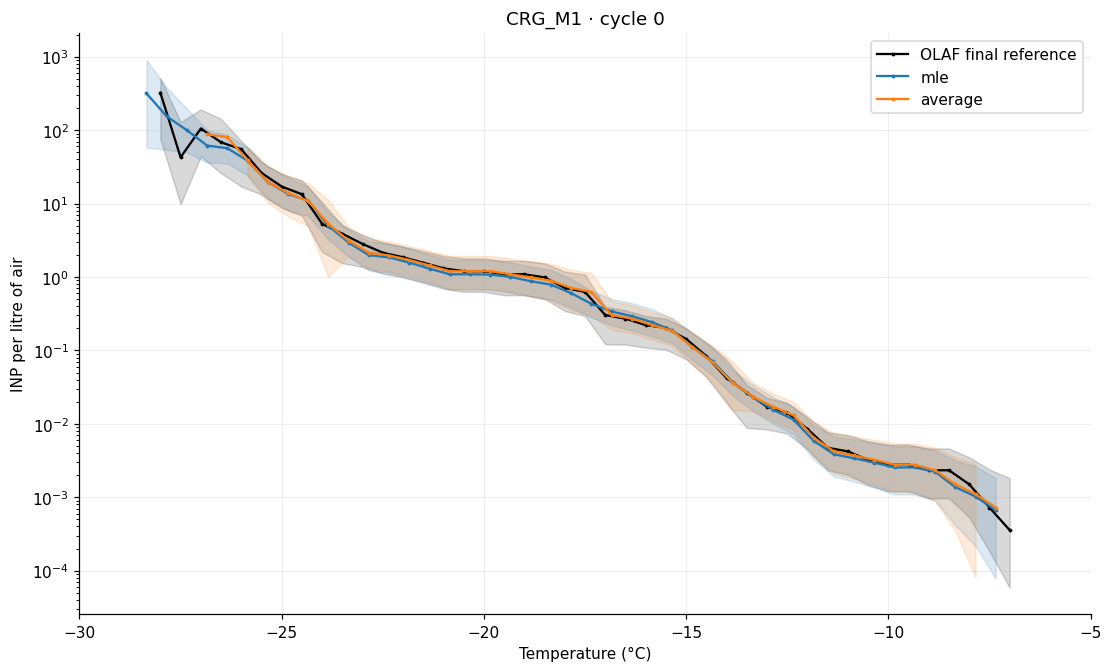

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
plot_spectrum(ax, reference.table, "OLAF final reference", "black", uncertainty=True)
for i, (method, table) in enumerate(combined_air.items()):
    plot_spectrum(ax, table.to_dataframe(), method, f"C{i}", uncertainty=True)
ax.set(yscale="log", xlabel="Temperature (°C)", ylabel="INP per litre of air",
       xlim=(-30, -5), title="CRG_M1 · cycle 0")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 7. Run the analysis in one call

`analyze_concentration()` runs the same calculation steps. Here we request the
combined curve and a separate curve for each sample input, using Average.


In [10]:
output_curves = {"CRG_M1": {"inputs": sample_inputs, "cycle": "0"}}
for name in sample_inputs:
    output_curves[name] = {"inputs": [name], "cycle": "0"}

result = inptk.analyze_concentration(
    experiment, method="average", curves=output_curves,
    temperature_step_C=0.5, temperature_method="latest",
    temperature_ranges_C=average_limits.temperature_ranges_C,
    output_basis="sampled_air",
)
result.curves["CRG_M1"].cumulative.to_dataframe().head()


,sample_id,curve_id,point_id,point_order,temperature_C,alignment,concentration,lower_error,upper_error,unit,...,dilution_fold,water_blank_ids,source_observations,uncertainty_method,correction_state,at_zero_boundary,is_extrapolated,used_in_final,final_selection_status,segment_id
0,CRG_M1,CRG_M1,point:0,0,20.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
1,CRG_M1,CRG_M1,point:1,1,20.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
2,CRG_M1,CRG_M1,point:2,2,19.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
3,CRG_M1,CRG_M1,point:3,3,19.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
4,CRG_M1,CRG_M1,point:4,4,18.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0


Use `result.curves["Sample_0"].cumulative` for an individual curve,
`result.curves["CRG_M1"].excluded` for excluded points, and `result.counts`
or `result.frozen_fraction` for the original observations.


## 8. Save when needed

Uncomment these lines to save the result and the combined concentration table.


In [11]:
# result.save("m1_analysis.inptk")
# result.export_csv("m1_concentration_air.csv", curve_id="CRG_M1")
